Tâche 1 : Comparaison ElasticNet
Implémenter le modèle ElasticNet (combinaison) L1 Et L2 régularisation).

Utilisez-le ElasticNetCVpour sélectionner les paramètres l1_ratioet alpha.
Comparez les métriques RMSE et le nombre de coefficients non nuls avec Ridge et Lasso purs sur l'ensemble de données sur le diabète.
Indice : l1_ratio=1 ceci est Lasso, l1_ratio=0ceci est Ridge.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")
data = load_diabetes()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [19]:
# 1. Implémenter ElasticNet et utiliser ElasticNetCV

# Définir la grille de valeurs pour alpha et l1_ratio
# L'indice suggère que l1_ratio=1 est Lasso et l1_ratio=0 est Ridge.
# ElasticNetCV prend une plage pour l1_ratio.
alphas = np.logspace(-4, 0, 20) # Une plage d'alphas courants
l1_ratios = np.linspace(0.01, 1.0, 20) # De près de Ridge (0) à Lasso (1)

elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=5, # 5-fold cross-validation
    random_state=42,
    n_jobs=-1 # Utiliser tous les cœurs disponibles
)
elastic_cv.fit(X_train, y_train)

# Meilleurs paramètres trouvés par ElasticNetCV
best_alpha_elastic = elastic_cv.alpha_
best_l1_ratio_elastic = elastic_cv.l1_ratio_

print(f"Meilleur alpha pour ElasticNet: {best_alpha_elastic:.4f}")
print(f"Meilleur l1_ratio pour ElasticNet: {best_l1_ratio_elastic:.4f}")

# 2. Entraîner le modèle ElasticNet avec les meilleurs paramètres
elastic_net_model = ElasticNet(
    alpha=best_alpha_elastic,
    l1_ratio=best_l1_ratio_elastic,
    random_state=42
)
elastic_net_model.fit(X_train, y_train)

# Prédictions et RMSE pour ElasticNet
y_pred_elastic = elastic_net_model.predict(X_test)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))

# Nombre de coefficients non nuls pour ElasticNet
non_zero_coeffs_elastic = np.sum(elastic_net_model.coef_ != 0)

print(f"RMSE pour ElasticNet: {rmse_elastic:.2f}")
print(f"Nombre de coefficients non nuls pour ElasticNet: {non_zero_coeffs_elastic}")

# 3. Comparer avec Ridge et Lasso purs

# Modèle Ridge
ridge_model = Ridge(alpha=best_alpha_elastic) # Utiliser le même alpha pour une comparaison équitable si possible
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
non_zero_coeffs_ridge = np.sum(ridge_model.coef_ != 0)

print(f"\nRMSE pour Ridge: {rmse_ridge:.2f}")
print(f"Nombre de coefficients non nuls pour Ridge: {non_zero_coeffs_ridge}")

# Modèle Lasso
lasso_model = Lasso(alpha=best_alpha_elastic, random_state=42) # Utiliser le même alpha
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
non_zero_coeffs_lasso = np.sum(lasso_model.coef_ != 0)

print(f"\nRMSE pour Lasso: {rmse_lasso:.2f}")
print(f"Nombre de coefficients non nuls pour Lasso: {non_zero_coeffs_lasso}")

# Rassembler les résultats dans un DataFrame pour une meilleure visualisation
results = pd.DataFrame({
    'Modèle': ['ElasticNet', 'Ridge', 'Lasso'],
    'RMSE': [rmse_elastic, rmse_ridge, rmse_lasso],
    'Coefficients non nuls': [non_zero_coeffs_elastic, non_zero_coeffs_ridge, non_zero_coeffs_lasso]
})

print("\nComparaison des modèles:")
print(results.to_markdown(index=False))

Meilleur alpha pour ElasticNet: 0.0030
Meilleur l1_ratio pour ElasticNet: 0.0100
RMSE pour ElasticNet: 53.10
Nombre de coefficients non nuls pour ElasticNet: 10

RMSE pour Ridge: 53.12
Nombre de coefficients non nuls pour Ridge: 10

RMSE pour Lasso: 53.12
Nombre de coefficients non nuls pour Lasso: 10

Comparaison des modèles:
| Modèle     |    RMSE |   Coefficients non nuls |
|:-----------|--------:|------------------------:|
| ElasticNet | 53.1044 |                      10 |
| Ridge      | 53.1201 |                      10 |
| Lasso      | 53.1182 |                      10 |


In [20]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 1.0],
    alphas=np.logspace(-3, 1, 20),
    cv=5,
    random_state=42
)
elastic.fit(X_train, y_train)


ElasticNetCV(alphas=array([1.00000000e-03, 1.62377674e-03, 2.63665090e-03, 4.28133240e-03,
       6.95192796e-03, 1.12883789e-02, 1.83298071e-02, 2.97635144e-02,
       4.83293024e-02, 7.84759970e-02, 1.27427499e-01, 2.06913808e-01,
       3.35981829e-01, 5.45559478e-01, 8.85866790e-01, 1.43844989e+00,
       2.33572147e+00, 3.79269019e+00, 6.15848211e+00, 1.00000000e+01]),
             cv=5, l1_ratio=[0.1, 0.5, 0.7, 1.0], random_state=42)

In [21]:
def evaluate(model):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    nonzero = np.sum(model.coef_ != 0)
    return rmse, r2, nonzero

results = pd.DataFrame({
    "Ridge": evaluate(ridge),
    "Lasso": evaluate(lasso),
    "ElasticNet": evaluate(elastic)
}, index=["RMSE", "R2", "Non-zero Coefs"])

results


,Ridge,Lasso,ElasticNet
RMSE,53.103902,53.076508,53.102502
R2,0.477610,0.478148,0.477637
Non-zero Coefs,10.000000,9.000000,10.000000


Tâche 2 : Impact du volume de données
Retour aux données synthétiques (onde sinusoïdale).

Réalisez une expérience avec différents nombres d'exemples d'entraînement : N= [ 20 , 50 , 100 , 500 ] .
Tracez le graphique de l'erreur sur le test en fonction de la quantité de données pour un polynôme du 10e degré avec et sans crête.
Question : La régularisation est-elle utile lorsqu'il y a peu de données ?

In [22]:
def generate_sine(n):
    X = np.linspace(0, 2*np.pi, n)
    y = np.sin(X) + np.random.randn(n) * 0.2
    return X.reshape(-1,1), y

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


In [23]:
N_values = [20, 50, 100, 500]
rmse_no_ridge = []
rmse_ridge = []

for N in N_values:
    X, y = generate_sine(N)
    X_test, y_test = generate_sine(500)

    # Polynôme degré 10
    model_no_ridge = make_pipeline(
        PolynomialFeatures(10),
        Ridge(alpha=0.0)
    )
    model_no_ridge.fit(X, y)
    pred1 = model_no_ridge.predict(X_test)
    rmse_no_ridge.append(np.sqrt(mean_squared_error(y_test, pred1)))

    model_ridge = make_pipeline(
        PolynomialFeatures(10),
        Ridge(alpha=1.0)
    )
    model_ridge.fit(X, y)
    pred2 = model_ridge.predict(X_test)
    rmse_ridge.append(np.sqrt(mean_squared_error(y_test, pred2)))


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.01019e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83152e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.09934e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.5254e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


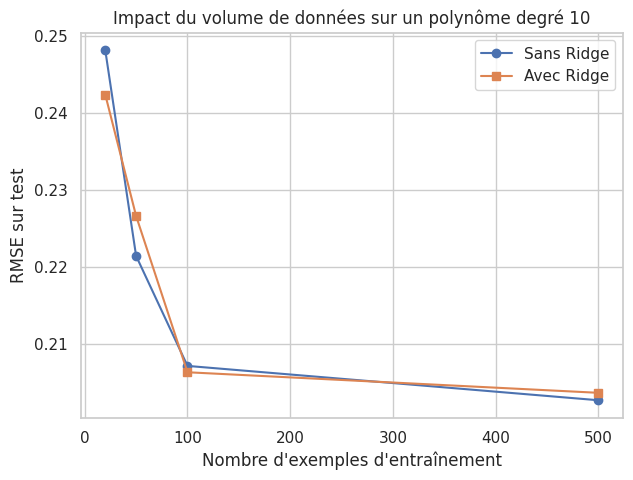

In [24]:
plt.figure(figsize=(7,5))
plt.plot(N_values, rmse_no_ridge, marker="o", label="Sans Ridge")
plt.plot(N_values, rmse_ridge, marker="s", label="Avec Ridge")
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("RMSE sur test")
plt.title("Impact du volume de données sur un polynôme degré 10")
plt.legend()
plt.show()


Tâche 3 : Analyse des résidus
Pour obtenir le meilleur modèle sur des données réelles, tracez le graphique « Réel vs Prédit » et l’histogramme des résidus.

Vérifiez l'hypothèse concernant la distribution normale des résidus (par exemple, le test de Shapiro-Wilk ou visuellement le graphique QQ).
Si les résidus ne sont pas normaux, qu'est-ce que cela pourrait indiquer ? (Indice : non-linéarité, hétéroscédasticité).

In [25]:
data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


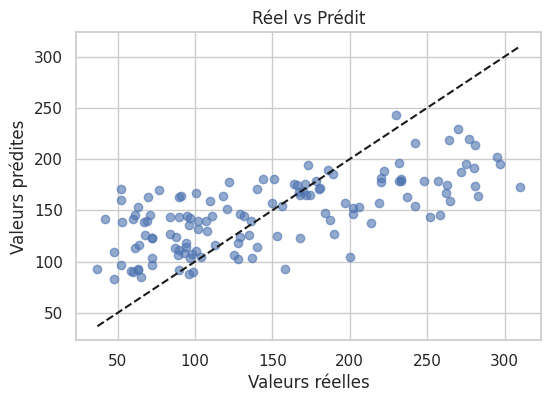

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")
plt.show()


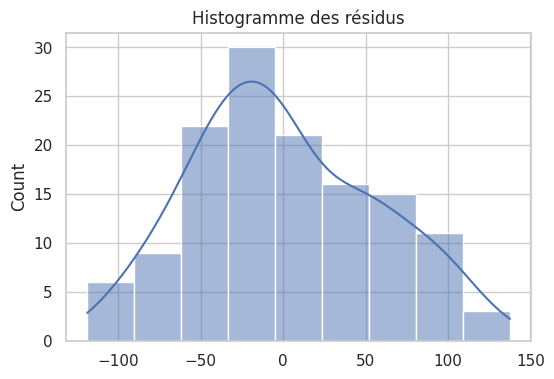

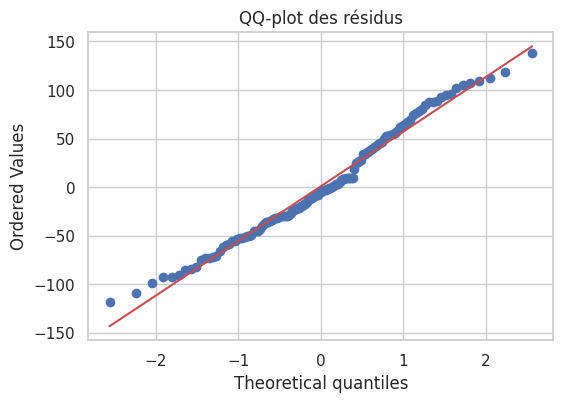

In [27]:
import scipy.stats as stats

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Histogramme des résidus")
plt.show()

# QQ-plot
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-plot des résidus")
plt.show()


In [28]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)
stat, p


(np.float64(0.9812616464140026), np.float64(0.06368630418827316))